# 01 - Data Collection EDA

Phạm vi dữ liệu ca sốt xuất huyết hiện có: **2022-2024** (chưa bao gồm 2020-2021).

Nguồn dân số/diện tích/mật độ: Tổng cục Thống kê, Niên giám thống kê TP.HCM 2023 (tổng hợp trong \data/raw/population.csv`).`

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['axes.facecolor'] = '#f8fafc'
plt.rcParams['figure.facecolor'] = '#ffffff'
pd.set_option('display.max_columns', None)

In [15]:
# Tự động tìm file dữ liệu dù chạy notebook từ thư mục project hay notebooks/
candidate_paths = [
    Path('data/raw/populations.csv'),
    Path('../data/raw/populations.csv')
]

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Không tìm thấy data/raw/populations.csv')

df = pd.read_csv(data_path, sep=';')
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['month'] = pd.to_numeric(df['month'], errors='coerce')
df['week'] = pd.to_numeric(df['week'], errors='coerce')
df['cases'] = pd.to_numeric(df['cases'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df['density'] = pd.to_numeric(df['density'], errors='coerce')
df['cases_per_100k'] = pd.to_numeric(df['cases_per_100k'], errors='coerce')

print(f'Using data file: {data_path.resolve()}')
print(f'Shape: {df.shape}')
df.head()

Using data file: D:\HK2_N3\graphmining\project_Graph\data\raw\populations.csv
Shape: (3432, 10)


,district_id,district_name,year,month,week,cases,population,area_km2,density,cases_per_100k
0,BC,Bình Chánh,2022,1,1,133,705508.0,252.69,2.793,18.852
1,BT,Bình Tân,2022,1,1,120,784173.0,52.02,15.074,15.303
2,BTH,Bình Thạnh,2022,1,1,52,499164.0,20.76,24.021,10.417
3,CG,Cần Giờ,2022,1,1,13,71526.0,704.45,102.000,18.175
4,CC,Củ Chi,2022,1,1,79,462047.0,434.77,1.063,17.098


In [16]:
df.isna().sum().sort_values(ascending=False).head(10)

district_id       0
district_name     0
year              0
month             0
week              0
cases             0
population        0
area_km2          0
density           0
cases_per_100k    0
dtype: int64

## 1) Phân phối số ca bệnh theo quận/huyện

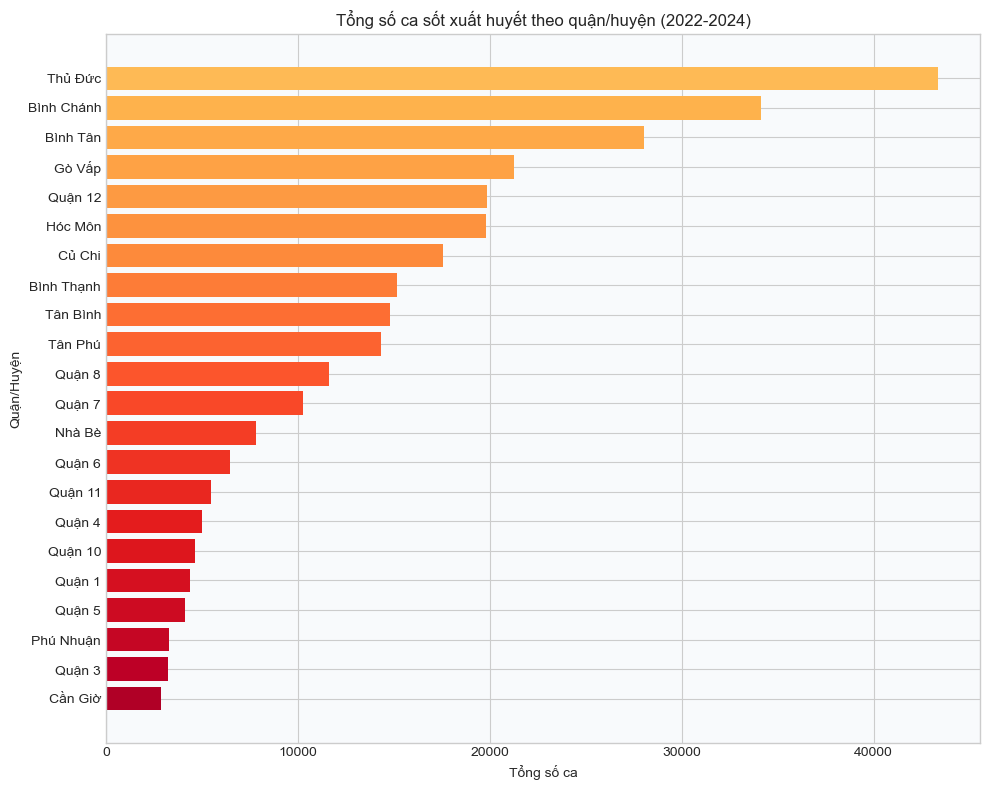

,district_name,cases
19,Thủ Đức,43377
0,Bình Chánh,34132
2,Bình Tân,28018
5,Gò Vấp,21276
12,Quận 12,19857
6,Hóc Môn,19777
4,Củ Chi,17547
1,Bình Thạnh,15153
20,Tân Bình,14794
21,Tân Phú,14336


In [17]:
cases_by_district = (
    df.groupby('district_name', as_index=False)['cases']
    .sum()
    .sort_values('cases', ascending=False)
)

plt.figure(figsize=(10, 8))
colors = plt.cm.YlOrRd(np.linspace(0.35, 0.9, len(cases_by_district)))
plt.barh(cases_by_district['district_name'], cases_by_district['cases'], color=colors)
plt.gca().invert_yaxis()
plt.title('Tổng số ca sốt xuất huyết theo quận/huyện (2022-2024)')
plt.xlabel('Tổng số ca')
plt.ylabel('Quận/Huyện')
plt.tight_layout()
plt.show()

cases_by_district.head(10)

## 2) Top 10 quận/huyện có số ca cao nhất

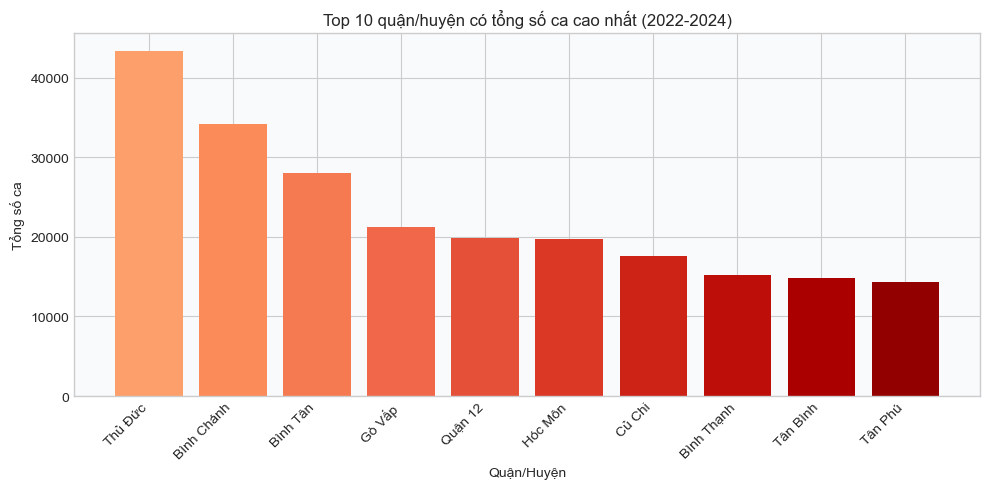

,district_name,cases
19,Thủ Đức,43377
0,Bình Chánh,34132
2,Bình Tân,28018
5,Gò Vấp,21276
12,Quận 12,19857
6,Hóc Môn,19777
4,Củ Chi,17547
1,Bình Thạnh,15153
20,Tân Bình,14794
21,Tân Phú,14336


In [18]:
top10 = cases_by_district.head(10).copy()

plt.figure(figsize=(10, 5))
top_colors = plt.cm.OrRd(np.linspace(0.45, 0.95, len(top10)))
plt.bar(top10['district_name'], top10['cases'], color=top_colors)
plt.title('Top 10 quận/huyện có tổng số ca cao nhất (2022-2024)')
plt.xlabel('Quận/Huyện')
plt.ylabel('Tổng số ca')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

top10

## 3) Phân tích mùa vụ theo tháng

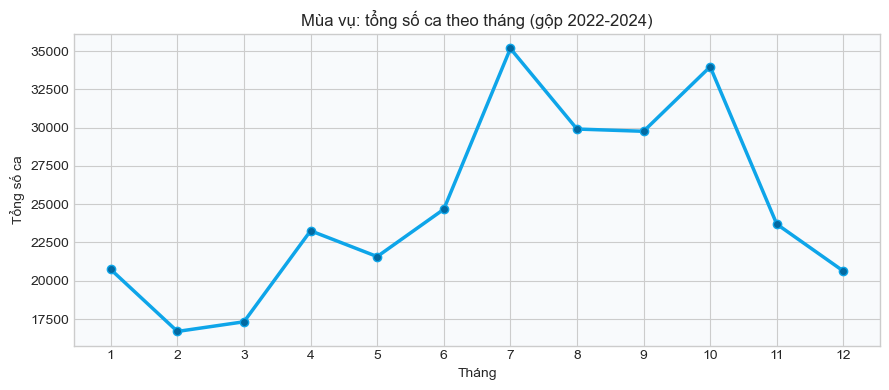

,month,cases
0,1,20736
1,2,16691
2,3,17322
3,4,23265
4,5,21579
5,6,24668
6,7,35167
7,8,29908
8,9,29760
9,10,33976


In [19]:
monthly_total = (
    df.groupby('month', as_index=False)['cases']
    .sum()
    .sort_values('month')
)

plt.figure(figsize=(9, 4))
plt.plot(
    monthly_total['month'],
    monthly_total['cases'],
    marker='o',
    color='#0ea5e9',
    linewidth=2.5,
    markerfacecolor='#0369a1'
)
plt.title('Mùa vụ: tổng số ca theo tháng (gộp 2022-2024)')
plt.xlabel('Tháng')
plt.ylabel('Tổng số ca')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

monthly_total

In [21]:
peak_month = monthly_total.loc[monthly_total['cases'].idxmax()]
print(f"Tháng có tổng số ca cao nhất (gộp 2022-2024): tháng {int(peak_month['month'])} với {int(peak_month['cases'])} ca")
peak_by_year = (
    df.groupby(['year', 'month'], as_index=False)['cases']
    .sum()
    .sort_values(['year', 'cases'], ascending=[True, False])
    .drop_duplicates(subset=['year'])
    .sort_values('year')
)
peak_by_year.rename(columns={'month': 'peak_month', 'cases': 'peak_cases'})

Tháng có tổng số ca cao nhất (gộp 2022-2024): tháng 7 với 35167 ca


,year,peak_month,peak_cases
6,2022,7,10143
18,2023,7,13381
30,2024,7,11643


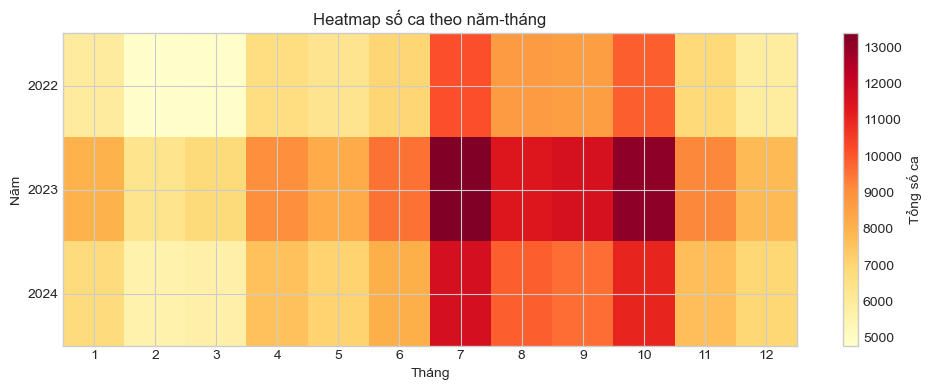

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2022,5951,4788,4860,6653,6328,7026,10143,8649,8581,9864,6888,5886
2023,7993,6358,6813,9011,8163,9532,13381,11381,11581,13099,9164,7807
2024,6792,5545,5649,7601,7088,8110,11643,9878,9598,11013,7646,6939


In [22]:
heatmap_df = (
    df.pivot_table(
        index='year',
        columns='month',
        values='cases',
        aggfunc='sum'
    )
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heatmap_df.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')

ax.set_title('Heatmap số ca theo năm-tháng')
ax.set_xlabel('Tháng')
ax.set_ylabel('Năm')
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns)
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Tổng số ca')

plt.tight_layout()
plt.show()

heatmap_df

## 4) Tỉ lệ mắc bệnh per 100.000 dân theo quận theo năm

In [23]:
yearly_district = (
    df.groupby(['year', 'district_name'], as_index=False)
    .agg(cases=('cases', 'sum'), population=('population', 'first'))
)
yearly_district['cases_per_100k_year'] = ((yearly_district['cases'] / yearly_district['population']) * 100000).round(3)
yearly_district = yearly_district.sort_values(['year', 'cases_per_100k_year'], ascending=[True, False])
yearly_district.head(20)

,year,district_name,cases,population,cases_per_100k_year
0,2022,Bình Chánh,9915,705508.0,1405.370
3,2022,Cần Giờ,807,71526.0,1128.261
7,2022,Nhà Bè,2285,206837.0,1104.735
4,2022,Củ Chi,5054,462047.0,1093.828
19,2022,Thủ Đức,12364,1169967.0,1056.782
6,2022,Hóc Môn,5680,542243.0,1047.501
2,2022,Bình Tân,8023,784173.0,1023.116
5,2022,Gò Vấp,6255,676899.0,924.067
12,2022,Quận 12,5614,620146.0,905.271
20,2022,Tân Bình,4284,474792.0,902.290


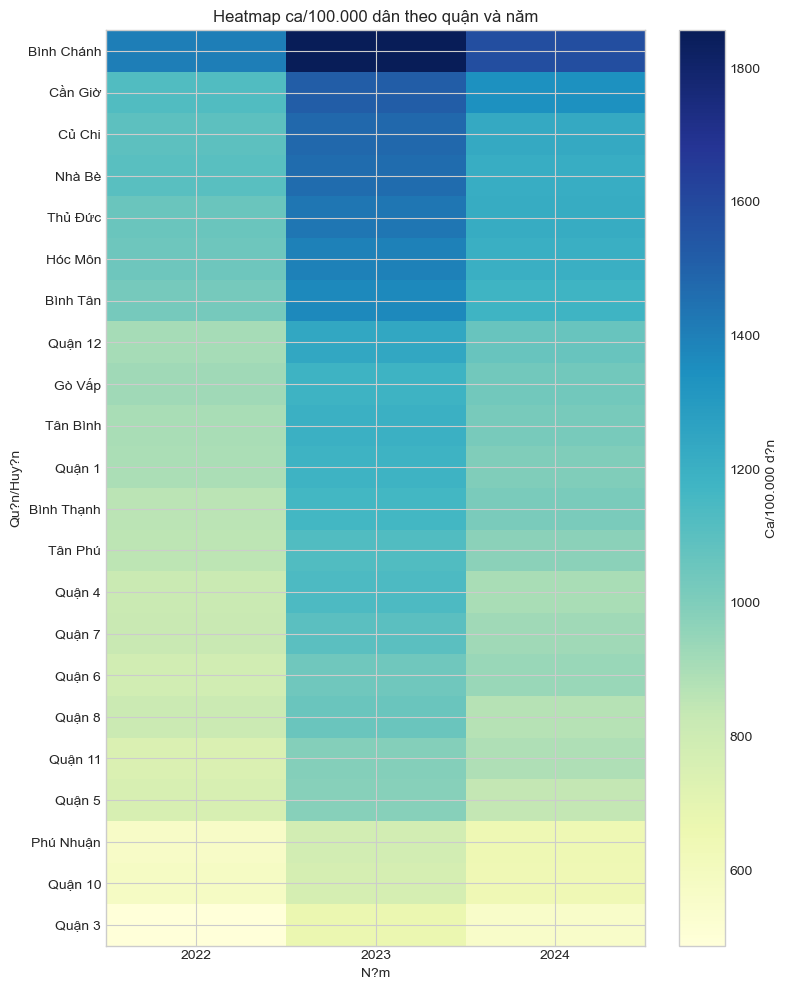

year,2022,2023,2024
district_name,,,
Bình Chánh,1405.370,1856.251,1576.311
Cần Giờ,1128.261,1514.135,1337.975
Củ Chi,1093.828,1477.339,1226.499
Nhà Bè,1104.735,1461.537,1213.032
Thủ Đức,1056.782,1431.664,1219.094
Hóc Môn,1047.501,1396.053,1203.704
Bình Tân,1023.116,1369.596,1180.224
Quận 12,905.271,1236.806,1059.912
Gò Vấp,924.067,1185.110,1033.980


In [24]:
heatmap_year_district = yearly_district.pivot(index='district_name', columns='year', values='cases_per_100k_year')
heatmap_year_district = heatmap_year_district.loc[heatmap_year_district.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heatmap_year_district.values, aspect='auto', cmap='YlGnBu', interpolation='nearest')
ax.set_title('Heatmap ca/100.000 dân theo quận và năm')
ax.set_xlabel('Năm')
ax.set_ylabel('Quận/Huyện')
ax.set_xticks(np.arange(len(heatmap_year_district.columns)))
ax.set_xticklabels(heatmap_year_district.columns)
ax.set_yticks(np.arange(len(heatmap_year_district.index)))
ax.set_yticklabels(heatmap_year_district.index)
fig.colorbar(im, ax=ax, label='Ca/100.000 dân')
plt.tight_layout()
plt.show()

heatmap_year_district

## 5) Correlation giữa dân số, mật độ và số ca bệnh

In [25]:
corr_cols = ['cases', 'population', 'density', 'cases_per_100k']
corr_matrix = df[corr_cols].corr(numeric_only=True)
corr_matrix

,cases,population,density,cases_per_100k
cases,1.000000,0.896514,-0.512478,0.615065
population,0.896514,1.000000,-0.542908,0.300963
density,-0.512478,-0.542908,1.000000,-0.175484
cases_per_100k,0.615065,0.300963,-0.175484,1.000000


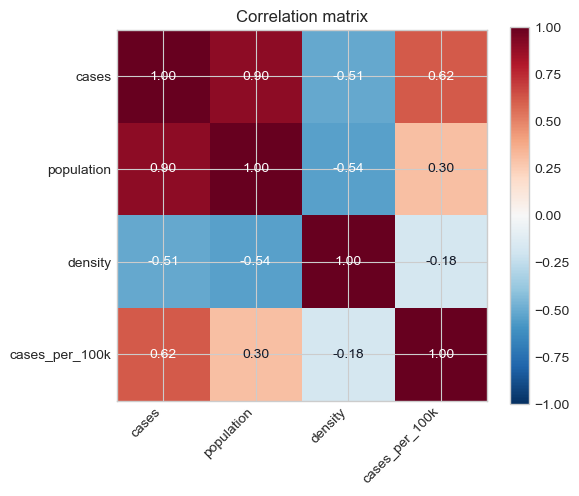

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap='RdBu_r')

ax.set_title('Correlation matrix')
ax.set_xticks(np.arange(len(corr_matrix.columns)))
ax.set_yticks(np.arange(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        txt_color = 'white' if abs(val) > 0.5 else '#111827'
        ax.text(j, i, f"{val:.2f}", ha='center', va='center', color=txt_color)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

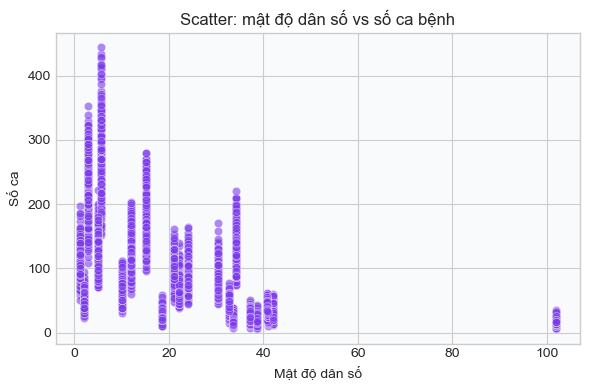

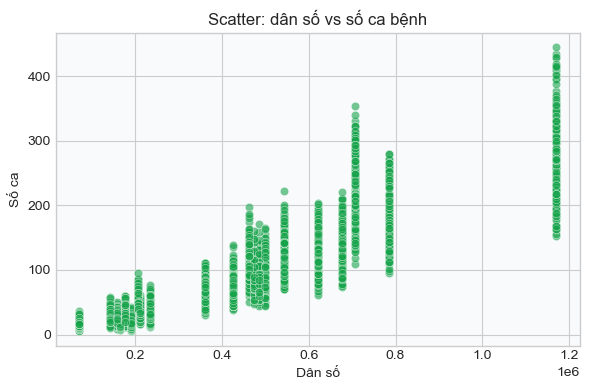

In [27]:
plt.figure(figsize=(6, 4))
plt.scatter(df['density'], df['cases'], alpha=0.6, color='#7c3aed', edgecolors='white', linewidths=0.4)
plt.title('Scatter: mật độ dân số vs số ca bệnh')
plt.xlabel('Mật độ dân số')
plt.ylabel('Số ca')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(df['population'], df['cases'], alpha=0.6, color='#16a34a', edgecolors='white', linewidths=0.4)
plt.title('Scatter: dân số vs số ca bệnh')
plt.xlabel('Dân số')
plt.ylabel('Số ca')
plt.tight_layout()
plt.show()

## 6) Heatmap số ca bệnh theo quận/huyện theo năm

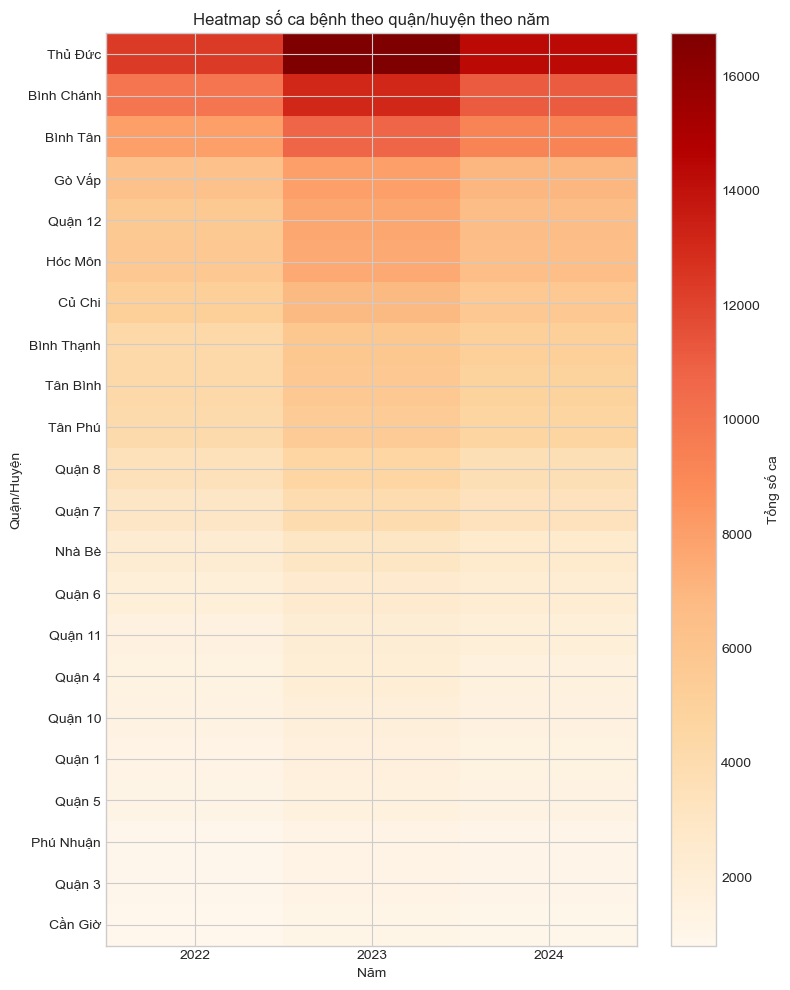

year,2022,2023,2024
district_name,,,
Thủ Đức,12364,16750,14263
Bình Chánh,9915,13096,11121
Bình Tân,8023,10740,9255
Gò Vấp,6255,8022,6999
Quận 12,5614,7670,6573
Hóc Môn,5680,7570,6527
Củ Chi,5054,6826,5667
Bình Thạnh,4286,5816,5051
Tân Bình,4284,5674,4836


In [28]:
cases_year_district = (
    df.groupby(['district_name', 'year'], as_index=False)['cases']
    .sum()
)

heatmap_cases_district_year = cases_year_district.pivot(
    index='district_name',
    columns='year',
    values='cases'
)
heatmap_cases_district_year = heatmap_cases_district_year.loc[
    heatmap_cases_district_year.sum(axis=1).sort_values(ascending=False).index
]

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(heatmap_cases_district_year.values, aspect='auto', cmap='OrRd', interpolation='nearest')

ax.set_title('Heatmap số ca bệnh theo quận/huyện theo năm')
ax.set_xlabel('Năm')
ax.set_ylabel('Quận/Huyện')
ax.set_xticks(np.arange(len(heatmap_cases_district_year.columns)))
ax.set_xticklabels(heatmap_cases_district_year.columns)
ax.set_yticks(np.arange(len(heatmap_cases_district_year.index)))
ax.set_yticklabels(heatmap_cases_district_year.index)
fig.colorbar(im, ax=ax, label='Tổng số ca')
plt.tight_layout()
plt.show()

heatmap_cases_district_year

## 7) Kết luận sơ bộ

- **Phân bố theo không gian:** số ca tập trung cao ở các quận/huyện đông dân (đặc biệt Thủ Đức, Bình Chánh, Bình Tân).
- **Mùa vụ:** ca bệnh tăng rõ ở giai đoạn mùa mưa, đỉnh tập trung quanh tháng 7.
- **Chuẩn hóa theo dân số:** khi quy đổi ca/100.000 dân, một số huyện ngoại thành nổi bật hơn so với xếp hạng theo tổng ca tuyệt đối.
- **Tương quan:** dân số liên hệ dương với số ca; mật độ không giải thích đầy đủ biến động ca bệnh.
- **Hạn chế hiện tại:** dữ liệu mới có 2022-2024; cần bổ sung 2020-2021 để đánh giá xu hướng dài hạn tốt hơn.